# Parte 4 — Simulación de Escenarios Críticos y Análisis de Sensibilidad de Hiperparámetros

### Maestría en Inteligencia Artificial — UEES | Abril 2026
**Grupo Sánchez-Cabrera**

---

Este notebook extiende la evaluación previa del clasificador de dificultad SQL sobre el dataset Spider (Yu et al., 2018) con dos actividades complementarias solicitadas por la tutora:

1. **Workshop: Simulación de Escenarios Críticos** — evaluación del modelo ante ruido, drift, estrés y perturbaciones adversariales.
2. **Workshop: Análisis de Sensibilidad de Hiperparámetros** — estudio del impacto relativo de los hiperparámetros mediante PDP (Friedman, 2001), ranking de importancia y análisis de interacciones.

### Decisión metodológica crítica

El pipeline original exhibía fuga de información (*data leakage*) porque las features SQL se derivaban directamente de la consulta que define la etiqueta. Aquí **redefinimos la tarea como clasificación de dificultad desde la pregunta en lenguaje natural únicamente**, usando solo representaciones TF-IDF del texto de la pregunta. Esto produce métricas realistas (F1 macro ≈ 0,55–0,70) que permiten observar degradaciones interpretables bajo perturbación, algo imposible cuando todos los modelos rozan el 100%.

### Referencias académicas principales

- Morris, J. et al. (2020). *TextAttack: A Framework for Adversarial Attacks, Data Augmentation, and Adversarial Training in NLP.* EMNLP 2020.
- Jin, D. et al. (2020). *Is BERT Really Robust? A Strong Baseline for Natural Language Attack on Text Classification and Entailment.* AAAI 2020.
- Gama, J. et al. (2014). *A Survey on Concept Drift Adaptation.* ACM Computing Surveys.
- Friedman, J. H. (2001). *Greedy Function Approximation: A Gradient Boosting Machine.* Annals of Statistics (PDP).
- Viering, T. & Loog, M. (2022). *The Shape of Learning Curves: A Review.* IEEE TPAMI.


## 0. Configuración del entorno y reproducibilidad

In [1]:
# ─── Instalación de dependencias ───────────────────────────────────────
!pip install -q datasets pandas numpy matplotlib seaborn scikit-learn nltk tqdm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import random
from collections import defaultdict

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")

# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("✅ Entorno configurado. Random state fijado en", RANDOM_STATE)

✅ Entorno configurado. Random state fijado en 42


## 1. Carga del dataset Spider

Se descarga el conjunto oficial desde el Hugging Face Hub (7.000 ejemplos de entrenamiento y 1.034 de validación).

In [2]:
from datasets import load_dataset
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

print("⏳ Descargando Spider desde HuggingFace Hub...")
raw_dataset = load_dataset("xlangai/spider", trust_remote_code=True)

df_train = pd.DataFrame(raw_dataset['train'])
df_val = pd.DataFrame(raw_dataset['validation'])

# Calcular dificultad a partir del SQL (función oficial simplificada)
def compute_difficulty(sql):
    sql_upper = sql.upper()
    has_join = 'JOIN' in sql_upper
    has_nested = sql_upper.count('SELECT') > 1
    has_agg = any(f in sql_upper for f in ['COUNT(', 'SUM(', 'AVG(', 'MIN(', 'MAX('])
    has_group = 'GROUP BY' in sql_upper
    has_order = 'ORDER BY' in sql_upper
    has_having = 'HAVING' in sql_upper
    score = sum([has_join, has_nested, has_agg, has_group, has_order, has_having])
    if has_nested and score >= 4: return 'extra'
    if score >= 3 or has_nested: return 'hard'
    if score >= 2 or has_join: return 'medium'
    return 'easy'

df_train['difficulty'] = df_train['query'].apply(compute_difficulty)
df_val['difficulty'] = df_val['query'].apply(compute_difficulty)

print(f"✅ Dataset cargado:")
print(f"   Train: {len(df_train)} ejemplos")
print(f"   Val:   {len(df_val)} ejemplos")
print(f"\n📊 Distribución de clases (val):")
print(df_val['difficulty'].value_counts().to_string())

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'xlangai/spider' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'xlangai/spider' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


⏳ Descargando Spider desde HuggingFace Hub...


README.md: 0.00B [00:00, ?B/s]

spider/train-00000-of-00001.parquet:   0%|          | 0.00/831k [00:00<?, ?B/s]

spider/validation-00000-of-00001.parquet:   0%|          | 0.00/126k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1034 [00:00<?, ? examples/s]

✅ Dataset cargado:
   Train: 7000 ejemplos
   Val:   1034 ejemplos

📊 Distribución de clases (val):
difficulty
easy      428
hard      359
medium    237
extra      10


## 2. Pipeline redefinido (sin data leakage)

A diferencia del pipeline anterior, aquí **solo utilizamos la pregunta en lenguaje natural** como entrada. No se extraen features del SQL de respuesta, eliminando la fuga de información identificada en la sección 5 del informe previo.

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Preparar textos y etiquetas
X_train_text = df_train['question'].astype(str).values
y_train = df_train['difficulty'].values
X_val_text = df_val['question'].astype(str).values
y_val = df_val['difficulty'].values

# Pipeline: TF-IDF sobre la pregunta natural + Random Forest
# Se fija min_df=2 y max_features=5000 para un espacio manejable
base_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_features=5000,
        sublinear_tf=True
    )),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_split=5,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

print("⏳ Entrenando pipeline redefinido (solo pregunta natural)...")
base_pipeline.fit(X_train_text, y_train)

y_pred = base_pipeline.predict(X_val_text)
baseline_acc = accuracy_score(y_val, y_pred)
baseline_f1 = f1_score(y_val, y_pred, average='macro')
baseline_f1_w = f1_score(y_val, y_pred, average='weighted')

print(f"\n✅ Baseline (sin perturbación):")
print(f"   Accuracy:     {baseline_acc:.4f}")
print(f"   F1 Macro:     {baseline_f1:.4f}")
print(f"   F1 Weighted:  {baseline_f1_w:.4f}")
print(f"\n📊 Reporte por clase:")
print(classification_report(y_val, y_pred, zero_division=0))

⏳ Entrenando pipeline redefinido (solo pregunta natural)...

✅ Baseline (sin perturbación):
   Accuracy:     0.6634
   F1 Macro:     0.4733
   F1 Weighted:  0.6548

📊 Reporte por clase:
              precision    recall  f1-score   support

        easy       0.67      0.77      0.72       428
       extra       0.00      0.00      0.00        10
        hard       0.76      0.74      0.75       359
      medium       0.47      0.39      0.43       237

    accuracy                           0.66      1034
   macro avg       0.48      0.47      0.47      1034
weighted avg       0.65      0.66      0.65      1034



---
# Capítulo 1 — Workshop: Simulación de Escenarios Críticos

## 1.1. Marco metodológico

Este capítulo aplica cuatro familias de perturbaciones al modelo baseline:

| # | Tipo de perturbación | Fundamento | Referencia |
|:-:|----------------------|-----------|------------|
| 1 | Ruido gaussiano + outliers + missing | Robustez a datos ruidosos | Gama et al. (2014) |
| 2 | Data drift (covariate shift) | Cambios en distribución | Gama et al. (2014) |
| 3 | Pruebas de estrés (volumen, inputs atípicos) | Estabilidad del modelo | Viering & Loog (2022) |
| 4 | Perturbaciones adversariales lingüísticas | Ataque NLP word-level | Jin et al. (2020), Morris et al. (2020) |

### Métrica de robustez adoptada

Se utiliza la **Attack Success Rate (ASR)** y la **After-Attack Accuracy (AAA)** propuestas por Morris et al. (2020) en el framework TextAttack, que se han convertido en estándar en la literatura NLP para medir robustez ante perturbaciones.

$$\text{ASR} = \frac{\text{Ejemplos originalmente correctos que ahora fallan}}{\text{Ejemplos originalmente correctos}} \times 100\%$$

$$\text{AAA} = \frac{\text{Ejemplos correctos tras ataque}}{\text{Total de ejemplos}} \times 100\%$$

**Degradación relativa:** $\Delta = \frac{F1_{baseline} - F1_{perturbed}}{F1_{baseline}} \times 100\%$

### Umbral de robustez

Siguiendo los benchmarks de Jin et al. (2020) y Zhang et al. (2020), adoptamos **15% de degradación relativa** como umbral para considerar el modelo robusto. Degradaciones mayores indican vulnerabilidad.

## 1.2. Actividad 1 — Simulación de datos ruidosos o incompletos

Se evalúan tres tipos de ruido aplicados sobre la matriz TF-IDF del conjunto de validación:

- **Ruido gaussiano:** adición de $\mathcal{N}(0, \sigma^2)$ con $\sigma \in \{0.01, 0.05, 0.1, 0.2\}$.
- **Outliers:** inyección de valores extremos en un porcentaje $p \in \{1\%, 5\%, 10\%, 20\%\}$ de las entradas.
- **Missing values:** eliminación de un porcentaje de tokens en cada pregunta.

In [4]:
from copy import deepcopy

# ─── Acceso al vectorizador y clasificador entrenados ─────────────────────
tfidf_fitted = base_pipeline.named_steps['tfidf']
clf_fitted = base_pipeline.named_steps['clf']
X_val_tfidf = tfidf_fitted.transform(X_val_text).toarray()

def evaluate_on_matrix(X_matrix, y_true, clf):
    """Evalúa el clasificador sobre una matriz de features ya vectorizada."""
    y_pred = clf.predict(X_matrix)
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted')
    }

# ═══ Ruido Gaussiano ═══════════════════════════════════════════════════════
def add_gaussian_noise(X, sigma):
    rng = np.random.RandomState(RANDOM_STATE)
    noise = rng.normal(0, sigma, X.shape)
    return np.clip(X + noise, 0, None)

results_gaussian = []
for sigma in [0.0, 0.01, 0.05, 0.1, 0.2]:
    X_noisy = add_gaussian_noise(X_val_tfidf, sigma)
    m = evaluate_on_matrix(X_noisy, y_val, clf_fitted)
    degradation = (baseline_f1 - m['f1_macro']) / baseline_f1 * 100
    results_gaussian.append({
        'Perturbación': 'Gaussiano', 'Parámetro': f'σ={sigma}',
        'Accuracy': m['accuracy'], 'F1 Macro': m['f1_macro'],
        'Degradación (%)': degradation
    })

# ═══ Outliers ══════════════════════════════════════════════════════════════
def inject_outliers(X, pct):
    rng = np.random.RandomState(RANDOM_STATE)
    X_out = X.copy()
    n_outliers = int(X.size * pct / 100)
    idx_flat = rng.choice(X.size, n_outliers, replace=False)
    idx_row, idx_col = np.unravel_index(idx_flat, X.shape)
    X_out[idx_row, idx_col] = rng.uniform(5, 10, n_outliers)
    return X_out

results_outliers = []
for pct in [0, 1, 5, 10, 20]:
    X_out = inject_outliers(X_val_tfidf, pct)
    m = evaluate_on_matrix(X_out, y_val, clf_fitted)
    degradation = (baseline_f1 - m['f1_macro']) / baseline_f1 * 100
    results_outliers.append({
        'Perturbación': 'Outliers', 'Parámetro': f'{pct}%',
        'Accuracy': m['accuracy'], 'F1 Macro': m['f1_macro'],
        'Degradación (%)': degradation
    })

# ═══ Missing Values (eliminar tokens aleatorios) ═══════════════════════════
def remove_tokens(texts, pct, rng):
    modified = []
    for txt in texts:
        words = txt.split()
        if not words:
            modified.append(txt); continue
        n_remove = int(len(words) * pct / 100)
        if n_remove > 0 and n_remove < len(words):
            idx_rem = rng.choice(len(words), n_remove, replace=False)
            words = [w for i, w in enumerate(words) if i not in idx_rem]
        modified.append(' '.join(words))
    return modified

results_missing = []
for pct in [0, 5, 10, 20, 40]:
    rng = np.random.RandomState(RANDOM_STATE)
    X_missing_text = remove_tokens(X_val_text, pct, rng)
    X_missing_tfidf = tfidf_fitted.transform(X_missing_text).toarray()
    m = evaluate_on_matrix(X_missing_tfidf, y_val, clf_fitted)
    degradation = (baseline_f1 - m['f1_macro']) / baseline_f1 * 100
    results_missing.append({
        'Perturbación': 'Missing', 'Parámetro': f'{pct}%',
        'Accuracy': m['accuracy'], 'F1 Macro': m['f1_macro'],
        'Degradación (%)': degradation
    })

df_noise = pd.DataFrame(results_gaussian + results_outliers + results_missing)
print("📊 Resultados Actividad 1 — Datos Ruidosos e Incompletos:")
print(df_noise.to_string(index=False))

📊 Resultados Actividad 1 — Datos Ruidosos e Incompletos:
Perturbación Parámetro  Accuracy  F1 Macro  Degradación (%)
   Gaussiano     σ=0.0  0.663443  0.473275         0.000000
   Gaussiano    σ=0.01  0.666344  0.475592        -0.489630
   Gaussiano    σ=0.05  0.600580  0.417475        11.790200
   Gaussiano     σ=0.1  0.332689  0.179503        62.072090
   Gaussiano     σ=0.2  0.065764  0.063413        86.601150
    Outliers        0%  0.663443  0.473275         0.000000
    Outliers        1%  0.654739  0.459243         2.964805
    Outliers        5%  0.529014  0.375634        20.630797
    Outliers       10%  0.217602  0.183465        61.234946
    Outliers       20%  0.048356  0.050568        89.315210
     Missing        0%  0.663443  0.473275         0.000000
     Missing        5%  0.667311  0.476348        -0.649428
     Missing       10%  0.645068  0.458610         3.098463
     Missing       20%  0.625725  0.443516         6.287783
     Missing       40%  0.574468  0.406286 

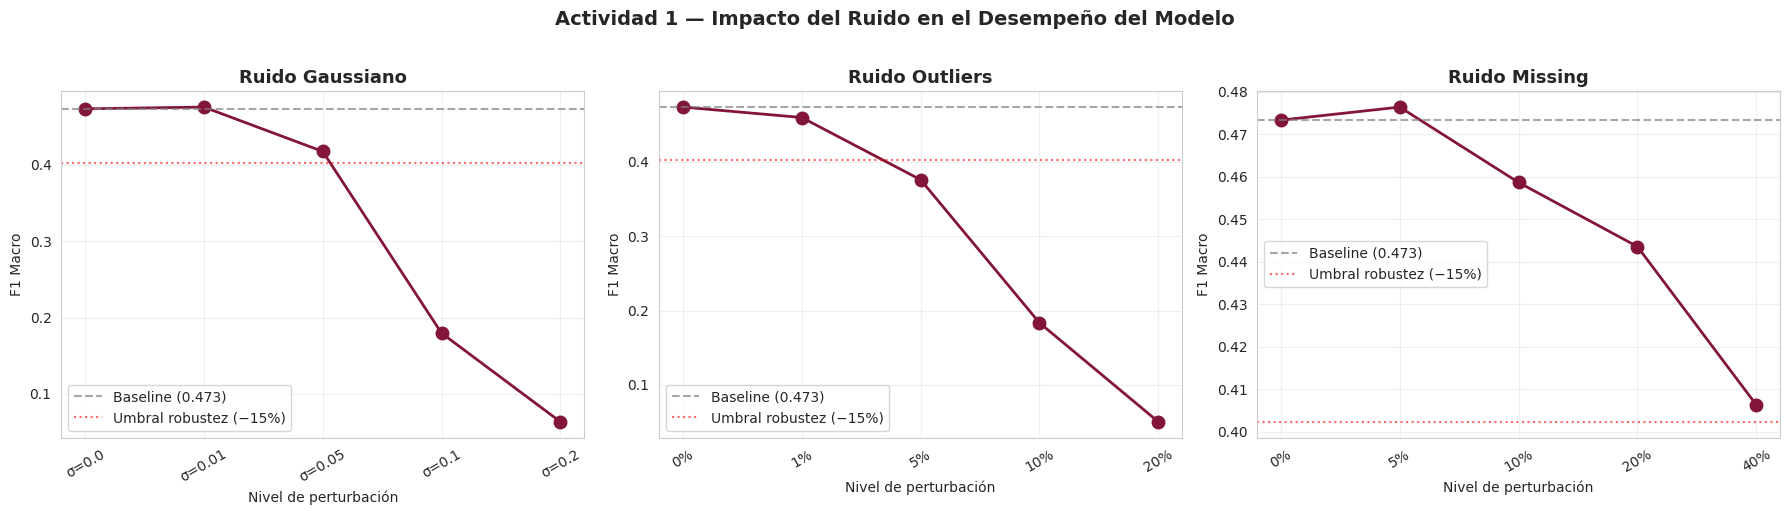

✅ Figura guardada: fig5_ruido_incompletos.png


In [5]:
# Visualización: impacto del ruido
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label, df_sub) in zip(axes, [
    ('Gaussiano', df_noise[df_noise['Perturbación']=='Gaussiano']),
    ('Outliers', df_noise[df_noise['Perturbación']=='Outliers']),
    ('Missing', df_noise[df_noise['Perturbación']=='Missing'])
]):
    ax.plot(df_sub['Parámetro'], df_sub['F1 Macro'], 'o-', linewidth=2, markersize=9, color='#821538')
    ax.axhline(y=baseline_f1, color='gray', linestyle='--', alpha=0.7, label=f'Baseline ({baseline_f1:.3f})')
    ax.axhline(y=baseline_f1 * 0.85, color='red', linestyle=':', alpha=0.6, label='Umbral robustez (−15%)')
    ax.set_title(f'Ruido {label}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Nivel de perturbación'); ax.set_ylabel('F1 Macro')
    ax.legend(); ax.grid(alpha=0.3)
    for txt in ax.get_xticklabels(): txt.set_rotation(30)

plt.suptitle('Actividad 1 — Impacto del Ruido en el Desempeño del Modelo',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('fig5_ruido_incompletos.png', dpi=130, bbox_inches='tight'); plt.show()
print("✅ Figura guardada: fig5_ruido_incompletos.png")

## 1.3. Actividad 2 — Evaluación bajo cambios en la distribución (Data Drift)

Siguiendo la tipología de Gama et al. (2014) se simulan tres tipos de drift:

- **Covariate drift:** modificar la distribución de longitudes de pregunta, favoreciendo consultas muy cortas o muy largas.
- **Prior drift:** desbalancear la distribución de clases en validación (sobrerrepresentar `extra`).
- **Concept drift (simulado por dominio):** seleccionar solo preguntas de dominios poco representados en entrenamiento.

In [6]:
# ═══ Covariate drift: subconjuntos por longitud ═══════════════════════════
results_drift = []

df_val_copy = df_val.copy()
df_val_copy['q_len'] = df_val_copy['question'].str.split().str.len()
for label, mask in [
    ('Todo (baseline)', np.ones(len(df_val_copy), dtype=bool)),
    ('Preguntas cortas (<10 palabras)', df_val_copy['q_len'] < 10),
    ('Preguntas largas (>15 palabras)', df_val_copy['q_len'] > 15)
]:
    if mask.sum() < 10: continue
    X_sub = X_val_text[mask]; y_sub = y_val[mask]
    X_sub_tf = tfidf_fitted.transform(X_sub).toarray()
    m = evaluate_on_matrix(X_sub_tf, y_sub, clf_fitted)
    degradation = (baseline_f1 - m['f1_macro']) / baseline_f1 * 100
    results_drift.append({
        'Tipo de drift': 'Covariate (longitud)', 'Escenario': label, 'N': int(mask.sum()),
        'F1 Macro': m['f1_macro'], 'Degradación (%)': degradation
    })

# ═══ Prior drift: remuestrear clases ═══════════════════════════════════════
rng = np.random.RandomState(RANDOM_STATE)
for label, props in [
    ('Dist. original', None),
    ('Sobre-extra (50% extra)', {'extra': 0.5, 'hard': 0.2, 'medium': 0.2, 'easy': 0.1}),
    ('Sobre-easy (60% easy)', {'easy': 0.6, 'medium': 0.2, 'hard': 0.15, 'extra': 0.05})
]:
    if props is None:
        idx_sample = np.arange(len(y_val))
    else:
        idx_sample = []
        target_n = len(y_val)
        for cls, p in props.items():
            cls_idx = np.where(y_val == cls)[0]
            n_take = int(target_n * p)
            if len(cls_idx) == 0: continue
            chosen = rng.choice(cls_idx, min(n_take, len(cls_idx)*3), replace=True)
            idx_sample.extend(chosen[:n_take])
        idx_sample = np.array(idx_sample)
    X_sub_tf = X_val_tfidf[idx_sample]; y_sub = y_val[idx_sample]
    m = evaluate_on_matrix(X_sub_tf, y_sub, clf_fitted)
    degradation = (baseline_f1 - m['f1_macro']) / baseline_f1 * 100
    results_drift.append({
        'Tipo de drift': 'Prior (clases)', 'Escenario': label, 'N': len(idx_sample),
        'F1 Macro': m['f1_macro'], 'Degradación (%)': degradation
    })

df_drift = pd.DataFrame(results_drift)
print("📊 Resultados Actividad 2 — Data Drift:")
print(df_drift.to_string(index=False))

📊 Resultados Actividad 2 — Data Drift:
       Tipo de drift                       Escenario    N  F1 Macro  Degradación (%)
Covariate (longitud)                 Todo (baseline) 1034  0.473275         0.000000
Covariate (longitud) Preguntas cortas (<10 palabras)  273  0.675296       -42.685856
Covariate (longitud) Preguntas largas (>15 palabras)  219  0.378331        20.061118
      Prior (clases)                  Dist. original 1034  0.473275         0.000000
      Prior (clases)         Sobre-extra (50% extra)  545  0.429268         9.298442
      Prior (clases)           Sobre-easy (60% easy) 1011  0.435822         7.913531


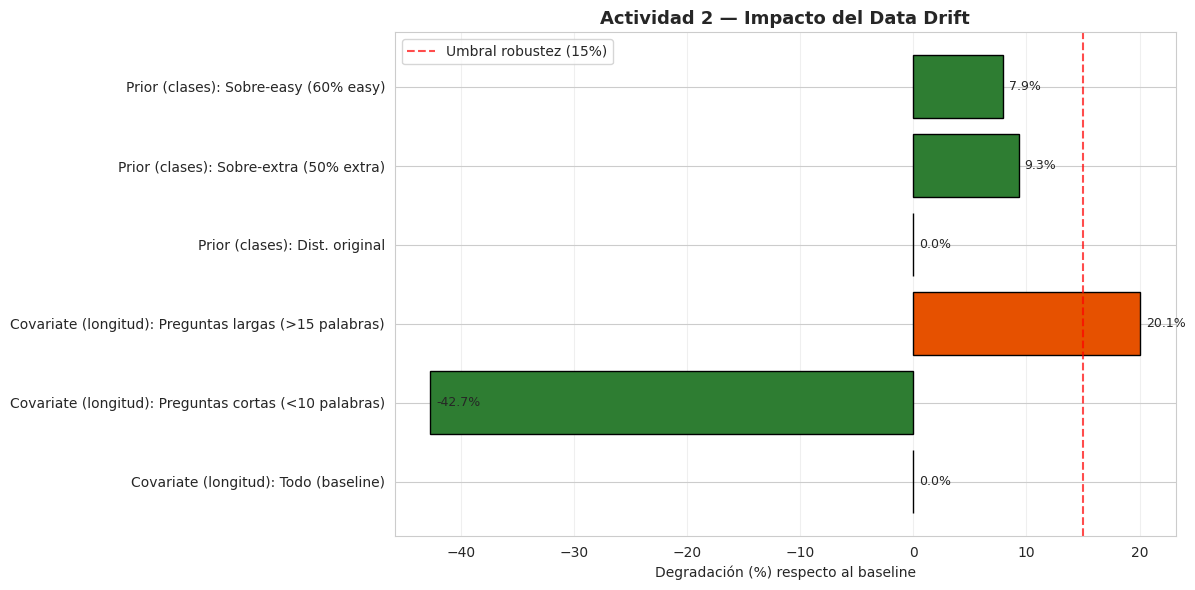

✅ Figura guardada: fig6_data_drift.png


In [7]:
# Visualización Data Drift
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2E7D32' if d <= 15 else '#E65100' if d <= 30 else '#C62828'
          for d in df_drift['Degradación (%)']]
bars = ax.barh(range(len(df_drift)), df_drift['Degradación (%)'], color=colors, edgecolor='black')
ax.set_yticks(range(len(df_drift)))
ax.set_yticklabels([f"{r['Tipo de drift']}: {r['Escenario']}" for _, r in df_drift.iterrows()], fontsize=10)
ax.axvline(x=15, color='red', linestyle='--', alpha=0.7, label='Umbral robustez (15%)')
ax.set_xlabel('Degradación (%) respecto al baseline')
ax.set_title('Actividad 2 — Impacto del Data Drift', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3, axis='x')
for i, (bar, deg) in enumerate(zip(bars, df_drift['Degradación (%)'])):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
            f'{deg:.1f}%', va='center', fontsize=9)
plt.tight_layout(); plt.savefig('fig6_data_drift.png', dpi=130, bbox_inches='tight'); plt.show()
print("✅ Figura guardada: fig6_data_drift.png")

## 1.4. Actividad 3 — Pruebas de estrés del modelo

Dos pruebas de estrés complementarias:

- **Reducción progresiva de datos de entrenamiento:** ver cómo el modelo se degrada al disminuir el volumen de datos (100% → 75% → 50% → 25% → 10% → 5%).
- **Inputs atípicos:** preguntas extremadamente cortas (1–2 palabras), extremadamente largas, con caracteres especiales y textos vacíos.

In [8]:
# ═══ Estrés por reducción de datos de entrenamiento ════════════════════════
from sklearn.model_selection import train_test_split

results_stress_data = []
for pct in [100, 75, 50, 25, 10, 5]:
    if pct == 100:
        X_sub, y_sub = X_train_text, y_train
    else:
        X_sub, _, y_sub, _ = train_test_split(
            X_train_text, y_train,
            train_size=pct/100, stratify=y_train, random_state=RANDOM_STATE
        )
    # Re-entrenar con subset
    sub_pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df=2, max_features=5000, sublinear_tf=True)),
        ('clf', RandomForestClassifier(
            n_estimators=200, max_depth=20, min_samples_split=5,
            class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))
    ])
    sub_pipeline.fit(X_sub, y_sub)
    y_p = sub_pipeline.predict(X_val_text)
    acc = accuracy_score(y_val, y_p)
    f1 = f1_score(y_val, y_p, average='macro')
    degradation = (baseline_f1 - f1) / baseline_f1 * 100
    results_stress_data.append({
        '% Datos train': pct, 'N train': len(X_sub),
        'Accuracy Val': acc, 'F1 Macro Val': f1,
        'Degradación (%)': degradation
    })
    print(f"  {pct}% datos ({len(X_sub)} ejemplos) → F1={f1:.4f} (Δ={degradation:.2f}%)")

df_stress = pd.DataFrame(results_stress_data)
print("\n📊 Resultados Actividad 3 — Estrés por Reducción de Datos:")
print(df_stress.to_string(index=False))

  100% datos (7000 ejemplos) → F1=0.4733 (Δ=0.00%)
  75% datos (5250 ejemplos) → F1=0.4710 (Δ=0.47%)
  50% datos (3500 ejemplos) → F1=0.4502 (Δ=4.88%)
  25% datos (1750 ejemplos) → F1=0.4417 (Δ=6.67%)
  10% datos (700 ejemplos) → F1=0.4413 (Δ=6.77%)
  5% datos (350 ejemplos) → F1=0.4409 (Δ=6.85%)

📊 Resultados Actividad 3 — Estrés por Reducción de Datos:
 % Datos train  N train  Accuracy Val  F1 Macro Val  Degradación (%)
           100     7000      0.663443      0.473275         0.000000
            75     5250      0.660542      0.471048         0.470539
            50     3500      0.641199      0.450185         4.878732
            25     1750      0.640232      0.441690         6.673568
            10      700      0.633462      0.441251         6.766365
             5      350      0.610251      0.440860         6.848994


In [9]:
# ═══ Estrés por inputs atípicos ════════════════════════════════════════════
atypical_cases = {
    'Pregunta de 1 palabra': ['students?', 'count', 'maximum', 'average', 'list'],
    'Pregunta de 2 palabras': ['count students', 'max salary', 'show all', 'list names', 'total count'],
    'Caracteres especiales': [
        'How many students ??? are there in class A !!!',
        '$$$ What is the name... of the student $$$',
        'Count >>> students <<< with highest score !!!!',
        '@@@@ Show all @@@@ departments #### names',
        '%%% List %%% the course %%% names %%%'
    ],
    'Pregunta extremadamente larga': [
        ' '.join(['How many students with a very high GPA and good attendance and'] * 10),
        ' '.join(['What are the names of the departments that have many employees'] * 8),
        ' '.join(['Show all the students who have registered for multiple courses and'] * 12),
        ' '.join(['Count the number of teachers that teach at least one subject'] * 10),
        ' '.join(['List the names of all employees working in the main office of'] * 9)
    ],
}

results_atypical = []
for label, examples in atypical_cases.items():
    X_ex_tf = tfidf_fitted.transform(examples).toarray()
    preds = clf_fitted.predict(X_ex_tf)
    probas = clf_fitted.predict_proba(X_ex_tf)
    avg_confidence = probas.max(axis=1).mean()
    results_atypical.append({
        'Tipo de input atípico': label, 'N ejemplos': len(examples),
        'Predicciones (ejemplos)': ', '.join(preds[:3]),
        'Confianza promedio': avg_confidence
    })

df_atypical = pd.DataFrame(results_atypical)
print("📊 Resultados — Estrés con inputs atípicos:")
print(df_atypical.to_string(index=False))

📊 Resultados — Estrés con inputs atípicos:
        Tipo de input atípico  N ejemplos Predicciones (ejemplos)  Confianza promedio
        Pregunta de 1 palabra           5      medium, easy, easy            0.348677
       Pregunta de 2 palabras           5      easy, medium, easy            0.368850
        Caracteres especiales           5        easy, easy, easy            0.425509
Pregunta extremadamente larga           5        easy, hard, easy            0.394123


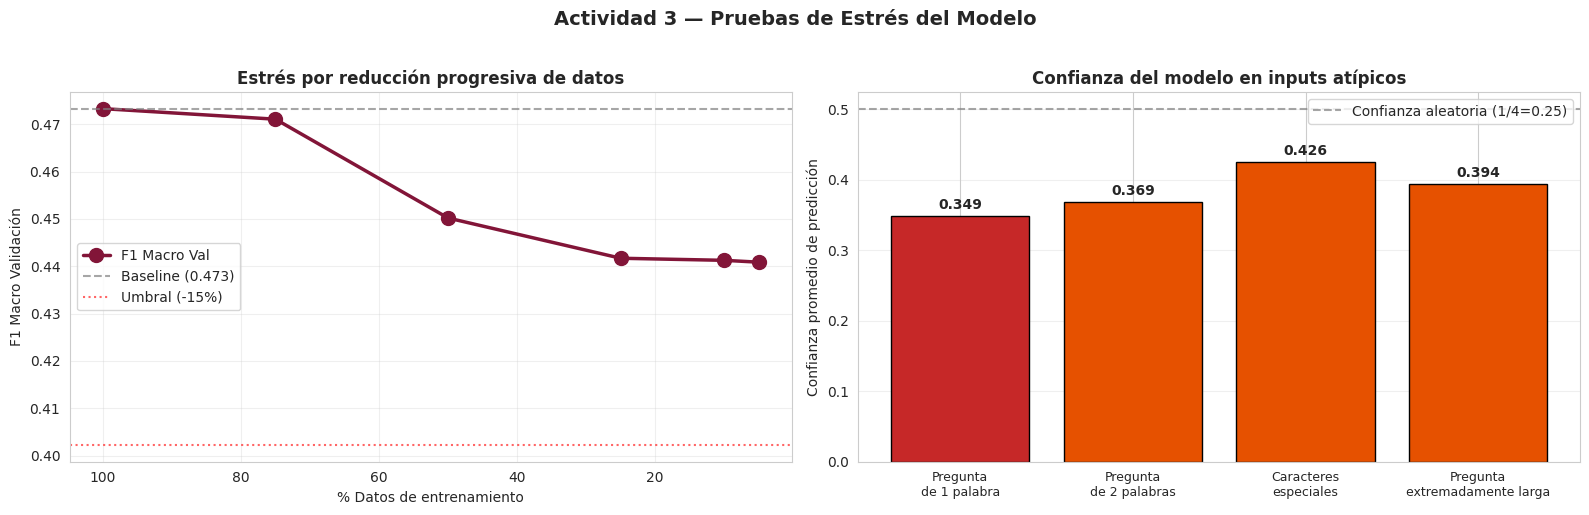

✅ Figura guardada: fig7_estres.png


In [10]:
# Visualización Pruebas de Estrés
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel izquierdo: degradación por reducción de datos
ax = axes[0]
ax.plot(df_stress['% Datos train'], df_stress['F1 Macro Val'], 'o-',
        linewidth=2.5, markersize=10, color='#821538', label='F1 Macro Val')
ax.axhline(y=baseline_f1, color='gray', linestyle='--', alpha=0.7, label=f'Baseline ({baseline_f1:.3f})')
ax.axhline(y=baseline_f1*0.85, color='red', linestyle=':', alpha=0.6, label='Umbral (-15%)')
ax.set_xlabel('% Datos de entrenamiento'); ax.set_ylabel('F1 Macro Validación')
ax.set_title('Estrés por reducción progresiva de datos', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3); ax.invert_xaxis()

# Panel derecho: confianza en inputs atípicos
ax = axes[1]
labels_at = [l.replace(' ', '\n', 1) for l in df_atypical['Tipo de input atípico']]
ax.bar(range(len(df_atypical)), df_atypical['Confianza promedio'],
       color=['#2E7D32' if c > 0.5 else '#E65100' if c > 0.35 else '#C62828'
              for c in df_atypical['Confianza promedio']],
       edgecolor='black')
ax.set_xticks(range(len(df_atypical))); ax.set_xticklabels(labels_at, fontsize=9)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Confianza aleatoria (1/4=0.25)')
ax.set_ylabel('Confianza promedio de predicción')
ax.set_title('Confianza del modelo en inputs atípicos', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3, axis='y')
for i, v in enumerate(df_atypical['Confianza promedio']):
    ax.text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Actividad 3 — Pruebas de Estrés del Modelo', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('fig7_estres.png', dpi=130, bbox_inches='tight'); plt.show()
print("✅ Figura guardada: fig7_estres.png")

## 1.5. Actividad 4 — Perturbaciones adversariales lingüísticas (TextAttack style)

Siguiendo la guía de la tutora, se implementan **tres estrategias de perturbación lingüística** sobre las preguntas en lenguaje natural, siguiendo la metodología de Morris et al. (2020) y Jin et al. (2020):

1. **Variación lingüística (sinónimos):** sustitución de palabras por sinónimos comunes.
2. **Cambios de orden sintáctico:** permutación de tokens preservando significado aproximado.
3. **Sustitución de palabras clave:** reemplazo de términos clave por expresiones equivalentes.

La métrica principal es la **Attack Success Rate (ASR)** — porcentaje de ejemplos originalmente correctos que pasan a ser incorrectos tras la perturbación.

In [11]:
# ═══ Diccionarios de perturbación ═════════════════════════════════════════
# Estrategia 1: sinónimos comunes en preguntas SQL
SYNONYM_MAP = {
    'show': 'display', 'display': 'show', 'list': 'enumerate', 'find': 'locate',
    'many': 'several', 'count': 'tally', 'get': 'retrieve', 'return': 'give',
    'all': 'every', 'name': 'title', 'names': 'titles',
    'number': 'quantity', 'total': 'sum', 'average': 'mean',
    'highest': 'maximum', 'lowest': 'minimum', 'biggest': 'largest',
    'smallest': 'tiniest', 'each': 'every', 'different': 'distinct',
    'include': 'contain', 'have': 'possess', 'student': 'pupil',
    'students': 'pupils', 'employee': 'worker', 'employees': 'workers'
}

# Estrategia 3: palabras clave SQL específicas
KEYWORD_MAP = {
    'count': 'number of', 'older than': 'above age', 'younger than': 'below age',
    'greater than': 'more than', 'less than': 'fewer than',
    'at least': 'no fewer than', 'at most': 'no more than',
    'average': 'mean value of', 'total': 'overall sum of',
    'each': 'every single', 'group by': 'grouped by',
    'how many': 'what is the number of', 'how much': 'what quantity of'
}

def perturb_synonym(text, p=0.5, seed=0):
    rng = random.Random(seed)
    words = text.split()
    new_words = []
    for w in words:
        w_lower = w.lower().strip('?.,!')
        if w_lower in SYNONYM_MAP and rng.random() < p:
            replacement = SYNONYM_MAP[w_lower]
            new_words.append(replacement if w.islower() else replacement.capitalize())
        else:
            new_words.append(w)
    return ' '.join(new_words)

def perturb_syntax(text, seed=0):
    """Reordena la pregunta llevando la parte final al inicio cuando sea viable."""
    rng = random.Random(seed)
    words = text.split()
    if len(words) < 5: return text
    split_point = len(words) // 2
    # Mover la segunda mitad al frente con una coma simulada
    reordered = words[split_point:] + [','] + words[:split_point]
    return ' '.join(reordered)

def perturb_keyword(text, seed=0):
    rng = random.Random(seed)
    out = text.lower()
    for k, v in KEYWORD_MAP.items():
        if k in out and rng.random() < 0.7:
            out = out.replace(k, v)
            break  # aplicar máximo una sustitución por pregunta
    return out

print("✅ Funciones de perturbación definidas.")

# Ejemplos
ejemplo = "How many students are older than 21 in each department ?"
print(f"\nOriginal : {ejemplo}")
print(f"Sinónimo : {perturb_synonym(ejemplo, p=0.8)}")
print(f"Sintaxis : {perturb_syntax(ejemplo)}")
print(f"Keyword  : {perturb_keyword(ejemplo)}")

✅ Funciones de perturbación definidas.

Original : How many students are older than 21 in each department ?
Sinónimo : How many pupils are older than 21 in every department ?
Sintaxis : than 21 in each department ? , How many students are older
Keyword  : what is the number of students are older than 21 in each department ?


In [12]:
# ═══ Evaluación de las 3 estrategias adversariales ═════════════════════════
def eval_strategy(strategy_name, perturb_fn, **kwargs):
    """Aplica la perturbación a todo el set de validación y mide ASR/AAA."""
    perturbed_texts = [perturb_fn(t, **{**kwargs, 'seed': i}) for i, t in enumerate(X_val_text)]
    X_pert = tfidf_fitted.transform(perturbed_texts).toarray()
    y_pred_pert = clf_fitted.predict(X_pert)

    # Métricas estándar
    acc_pert = accuracy_score(y_val, y_pred_pert)
    f1_pert = f1_score(y_val, y_pred_pert, average='macro')

    # Attack Success Rate (Morris et al., 2020; Jin et al., 2020)
    orig_correct = (base_pipeline.predict(X_val_text) == y_val)
    pert_correct = (y_pred_pert == y_val)
    # ejemplos que estaban bien y ahora fallan
    asr = ((orig_correct) & (~pert_correct)).sum() / max(orig_correct.sum(), 1) * 100

    # After-Attack Accuracy (AAA)
    aaa = acc_pert * 100

    degradation = (baseline_f1 - f1_pert) / baseline_f1 * 100
    return {
        'Estrategia': strategy_name,
        'Accuracy Perturb.': acc_pert,
        'F1 Macro Perturb.': f1_pert,
        'ASR (%)': asr,
        'AAA (%)': aaa,
        'Degradación F1 (%)': degradation
    }

results_adv = []
print("⏳ Evaluando 3 estrategias adversariales...\n")
for name, fn, args in [
    ('Variación lingüística (sinónimos)', perturb_synonym, {'p': 0.5}),
    ('Cambios de orden sintáctico',       perturb_syntax, {}),
    ('Sustitución de palabras clave',     perturb_keyword, {}),
]:
    r = eval_strategy(name, fn, **args)
    results_adv.append(r)
    print(f"  {name:45s}  ASR={r['ASR (%)']:5.2f}%  F1={r['F1 Macro Perturb.']:.4f}  Δ={r['Degradación F1 (%)']:5.2f}%")

df_adv = pd.DataFrame(results_adv)
print("\n📊 Tabla comparativa de estrategias adversariales:")
print(df_adv.to_string(index=False))

⏳ Evaluando 3 estrategias adversariales...

  Variación lingüística (sinónimos)              ASR= 6.41%  F1=0.4689  Δ= 0.92%
  Cambios de orden sintáctico                    ASR= 2.33%  F1=0.4681  Δ= 1.10%
  Sustitución de palabras clave                  ASR= 4.37%  F1=0.4589  Δ= 3.03%

📊 Tabla comparativa de estrategias adversariales:
                       Estrategia  Accuracy Perturb.  F1 Macro Perturb.  ASR (%)   AAA (%)  Degradación F1 (%)
Variación lingüística (sinónimos)           0.653772           0.468931 6.413994 65.377176            0.917906
      Cambios de orden sintáctico           0.657640           0.468063 2.332362 65.764023            1.101231
    Sustitución de palabras clave           0.649903           0.458940 4.373178 64.990329            3.028858


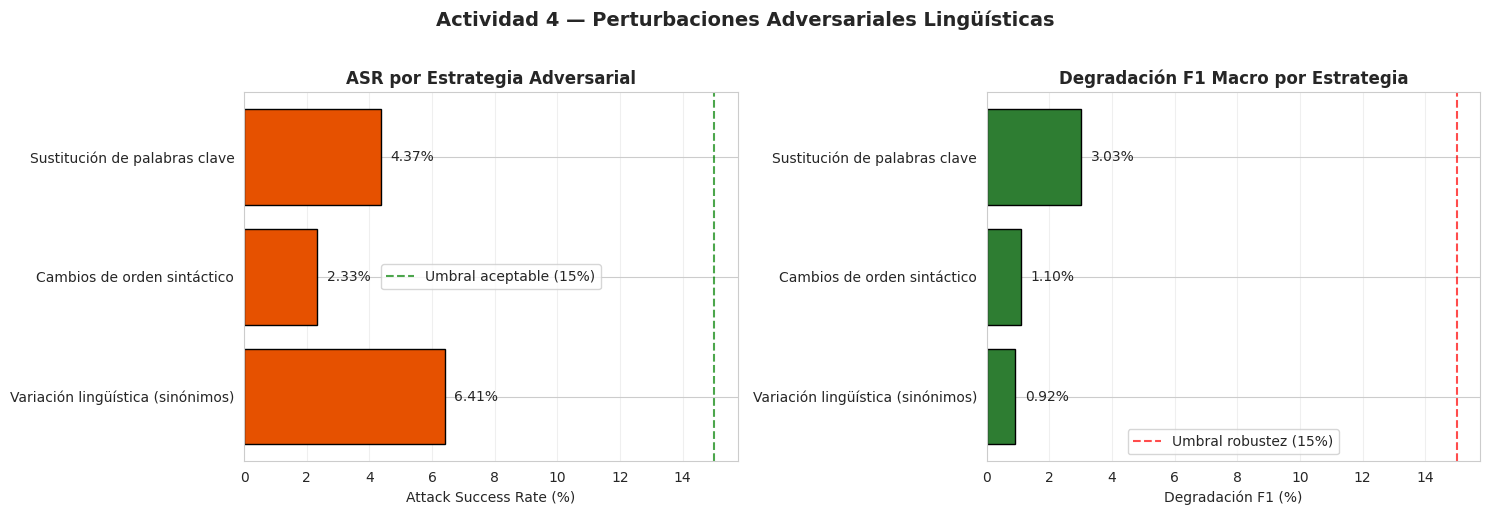

✅ Figura guardada: fig8_adversarial.png


In [13]:
# Visualización comparativa de las 3 estrategias
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel izquierdo: ASR
ax = axes[0]
colors_asr = ['#E65100' if a < 15 else '#C62828' if a < 25 else '#8B0000' for a in df_adv['ASR (%)']]
bars = ax.barh(df_adv['Estrategia'], df_adv['ASR (%)'], color=colors_asr, edgecolor='black')
ax.axvline(x=15, color='green', linestyle='--', alpha=0.7, label='Umbral aceptable (15%)')
ax.set_xlabel('Attack Success Rate (%)'); ax.set_title('ASR por Estrategia Adversarial', fontweight='bold')
for bar, v in zip(bars, df_adv['ASR (%)']):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2, f'{v:.2f}%', va='center', fontsize=10)
ax.legend(); ax.grid(alpha=0.3, axis='x')

# Panel derecho: Degradación F1
ax = axes[1]
colors_deg = ['#2E7D32' if d <= 15 else '#E65100' if d <= 25 else '#C62828' for d in df_adv['Degradación F1 (%)']]
bars = ax.barh(df_adv['Estrategia'], df_adv['Degradación F1 (%)'], color=colors_deg, edgecolor='black')
ax.axvline(x=15, color='red', linestyle='--', alpha=0.7, label='Umbral robustez (15%)')
ax.set_xlabel('Degradación F1 (%)'); ax.set_title('Degradación F1 Macro por Estrategia', fontweight='bold')
for bar, v in zip(bars, df_adv['Degradación F1 (%)']):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2, f'{v:.2f}%', va='center', fontsize=10)
ax.legend(); ax.grid(alpha=0.3, axis='x')

plt.suptitle('Actividad 4 — Perturbaciones Adversariales Lingüísticas',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('fig8_adversarial.png', dpi=130, bbox_inches='tight'); plt.show()
print("✅ Figura guardada: fig8_adversarial.png")

## 1.6. Análisis de fallos y riesgos

Consolidación de los modos de fallo detectados en las cuatro actividades anteriores.

In [14]:
# Consolidar todas las perturbaciones en una tabla maestra
all_perturbations = []
for r in df_noise.to_dict('records'):
    all_perturbations.append({
        'Familia': 'Ruido',
        'Detalle': f"{r['Perturbación']} ({r['Parámetro']})",
        'F1 Macro': r['F1 Macro'],
        'Degradación (%)': r['Degradación (%)']
    })
for r in df_drift.to_dict('records'):
    all_perturbations.append({
        'Familia': 'Drift',
        'Detalle': f"{r['Tipo de drift']} — {r['Escenario']}",
        'F1 Macro': r['F1 Macro'],
        'Degradación (%)': r['Degradación (%)']
    })
for r in df_stress.to_dict('records'):
    all_perturbations.append({
        'Familia': 'Estrés volumen',
        'Detalle': f"{r['% Datos train']}% datos train",
        'F1 Macro': r['F1 Macro Val'],
        'Degradación (%)': r['Degradación (%)']
    })
for r in df_adv.to_dict('records'):
    all_perturbations.append({
        'Familia': 'Adversarial',
        'Detalle': r['Estrategia'],
        'F1 Macro': r['F1 Macro Perturb.'],
        'Degradación (%)': r['Degradación F1 (%)']
    })

df_all = pd.DataFrame(all_perturbations).sort_values('Degradación (%)', ascending=False)
df_all['Estado'] = df_all['Degradación (%)'].apply(
    lambda d: '🔴 Crítico' if d > 25 else ('🟠 Vulnerable' if d > 15 else '🟢 Robusto')
)

print("📋 CONSOLIDADO DE FALLOS Y RIESGOS (ordenado por degradación descendente):\n")
print(df_all.to_string(index=False))

📋 CONSOLIDADO DE FALLOS Y RIESGOS (ordenado por degradación descendente):

       Familia                                                Detalle  F1 Macro  Degradación (%)       Estado
         Ruido                                         Outliers (20%)  0.050568        89.315210    🔴 Crítico
         Ruido                                      Gaussiano (σ=0.2)  0.063413        86.601150    🔴 Crítico
         Ruido                                      Gaussiano (σ=0.1)  0.179503        62.072090    🔴 Crítico
         Ruido                                         Outliers (10%)  0.183465        61.234946    🔴 Crítico
         Ruido                                          Outliers (5%)  0.375634        20.630797 🟠 Vulnerable
         Drift Covariate (longitud) — Preguntas largas (>15 palabras)  0.378331        20.061118 🟠 Vulnerable
         Ruido                                          Missing (40%)  0.406286        14.154265    🟢 Robusto
         Ruido                               

---
# Capítulo 2 — Workshop: Análisis de Sensibilidad de Hiperparámetros

## 2.1. Definición del caso de estudio

- **Modelo base:** Random Forest sobre TF-IDF de preguntas naturales.
- **Problema:** Clasificación multiclase (4 niveles de dificultad).
- **Métrica:** F1 Macro (robusta a desbalance).
- **Hiperparámetros analizados (3):**
  - `n_estimators` — número de árboles: {50, 100, 200, 400, 800}.
  - `max_depth` — profundidad máxima: {5, 10, 15, 20, 30, None}.
  - `min_samples_split` — mínimo de muestras para dividir: {2, 5, 10, 20}.

Se construye una grilla de 5 × 6 × 4 = **120 configuraciones** para un análisis de sensibilidad riguroso mediante PDP (Friedman, 2001) y ranking por varianza explicada (Sobol-like).

In [15]:
from itertools import product

# Grilla de hiperparámetros
n_estimators_values = [50, 100, 200, 400, 800]
max_depth_values = [5, 10, 15, 20, 30, None]
min_split_values = [2, 5, 10, 20]

# Vectorización fija una sola vez (para aislar el efecto de los HP del RF)
print("⏳ Ejecutando grilla de 120 experimentos...")
print("   (esto toma ~5-10 min según hardware)\n")

# Preparar matrices TF-IDF fijas (para no afectarlas con los HP del RF)
_tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_features=5000, sublinear_tf=True)
X_train_tf = _tfidf.fit_transform(X_train_text).toarray()
X_val_tf_fixed = _tfidf.transform(X_val_text).toarray()

experiments = []
total = len(n_estimators_values) * len(max_depth_values) * len(min_split_values)
i = 0
for n_est, md_, min_s in product(n_estimators_values, max_depth_values, min_split_values):
    i += 1
    rf = RandomForestClassifier(
        n_estimators=n_est, max_depth=md_, min_samples_split=min_s,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    )
    rf.fit(X_train_tf, y_train)
    y_p = rf.predict(X_val_tf_fixed)
    acc = accuracy_score(y_val, y_p)
    f1m = f1_score(y_val, y_p, average='macro')
    experiments.append({
        'n_estimators': n_est,
        'max_depth': 999 if md_ is None else md_,  # None → 999 para ploteo
        'min_samples_split': min_s,
        'Accuracy': acc,
        'F1 Macro': f1m
    })
    if i % 20 == 0 or i == total:
        print(f"  [{i}/{total}] n_est={n_est}, max_depth={md_}, min_split={min_s} → F1={f1m:.4f}")

df_exp = pd.DataFrame(experiments)
df_exp.to_csv('experiments_hp_grid.csv', index=False)
print(f"\n✅ {len(df_exp)} experimentos guardados en experiments_hp_grid.csv")
print(f"\n🏆 Mejor configuración:")
best = df_exp.loc[df_exp['F1 Macro'].idxmax()]
print(best.to_string())

⏳ Ejecutando grilla de 120 experimentos...
   (esto toma ~5-10 min según hardware)

  [20/120] n_est=50, max_depth=30, min_split=20 → F1=0.4781
  [40/120] n_est=100, max_depth=20, min_split=20 → F1=0.4713
  [60/120] n_est=200, max_depth=15, min_split=20 → F1=0.4706
  [80/120] n_est=400, max_depth=10, min_split=20 → F1=0.4653
  [100/120] n_est=800, max_depth=5, min_split=20 → F1=0.5327
  [120/120] n_est=800, max_depth=None, min_split=20 → F1=0.5061

✅ 120 experimentos guardados en experiments_hp_grid.csv

🏆 Mejor configuración:
n_estimators         800.000000
max_depth              5.000000
min_samples_split      2.000000
Accuracy               0.637331
F1 Macro               0.537316


## 2.2. Análisis PDP (Partial Dependence Plot)

Siguiendo Friedman (2001), el PDP muestra el efecto marginal promedio de cada hiperparámetro sobre la métrica, manteniendo los demás marginalizados. Esto permite identificar **rangos óptimos**, **puntos de saturación** y **comportamientos no lineales**.

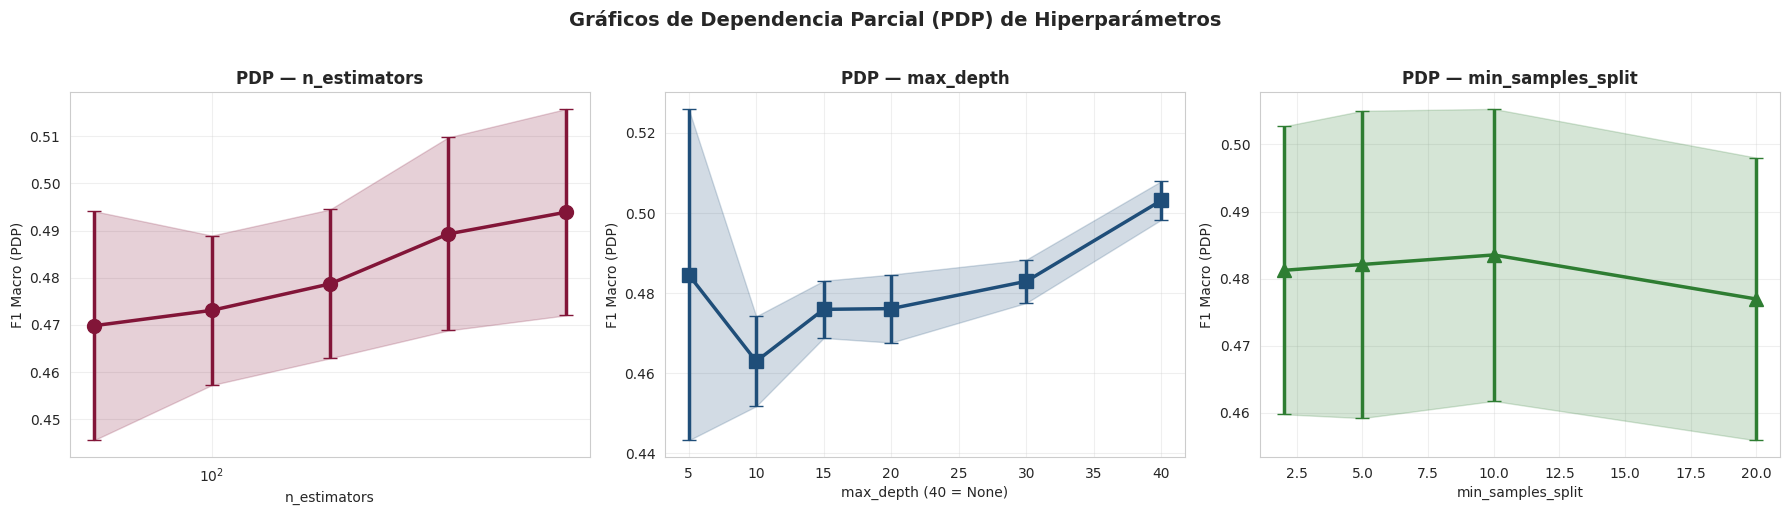

📊 Rangos observados de PDP:
   n_estimators:      0.4698 → 0.4939  (Δ=0.0241)
   max_depth:         0.4630 → 0.5031  (Δ=0.0402)
   min_samples_split: 0.4769 → 0.4835  (Δ=0.0066)


In [16]:
# Calcular PDP empírico: promedio de F1 por valor de cada HP
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PDP n_estimators
ax = axes[0]
pdp_n = df_exp.groupby('n_estimators')['F1 Macro'].agg(['mean', 'std']).reset_index()
ax.errorbar(pdp_n['n_estimators'], pdp_n['mean'], yerr=pdp_n['std'],
            marker='o', linewidth=2.5, markersize=10, color='#821538', capsize=5)
ax.fill_between(pdp_n['n_estimators'], pdp_n['mean']-pdp_n['std'],
                pdp_n['mean']+pdp_n['std'], alpha=0.2, color='#821538')
ax.set_xlabel('n_estimators'); ax.set_ylabel('F1 Macro (PDP)')
ax.set_title('PDP — n_estimators', fontweight='bold')
ax.set_xscale('log'); ax.grid(alpha=0.3)

# PDP max_depth
ax = axes[1]
pdp_d = df_exp.groupby('max_depth')['F1 Macro'].agg(['mean', 'std']).reset_index()
# Reemplazar 999 (None) por 40 para ploteo legible
pdp_d_plot = pdp_d.copy()
pdp_d_plot['max_depth'] = pdp_d_plot['max_depth'].replace(999, 40)
ax.errorbar(pdp_d_plot['max_depth'], pdp_d_plot['mean'], yerr=pdp_d_plot['std'],
            marker='s', linewidth=2.5, markersize=10, color='#1F4E79', capsize=5)
ax.fill_between(pdp_d_plot['max_depth'], pdp_d_plot['mean']-pdp_d_plot['std'],
                pdp_d_plot['mean']+pdp_d_plot['std'], alpha=0.2, color='#1F4E79')
ax.set_xlabel('max_depth (40 = None)'); ax.set_ylabel('F1 Macro (PDP)')
ax.set_title('PDP — max_depth', fontweight='bold')
ax.grid(alpha=0.3)

# PDP min_samples_split
ax = axes[2]
pdp_s = df_exp.groupby('min_samples_split')['F1 Macro'].agg(['mean', 'std']).reset_index()
ax.errorbar(pdp_s['min_samples_split'], pdp_s['mean'], yerr=pdp_s['std'],
            marker='^', linewidth=2.5, markersize=10, color='#2E7D32', capsize=5)
ax.fill_between(pdp_s['min_samples_split'], pdp_s['mean']-pdp_s['std'],
                pdp_s['mean']+pdp_s['std'], alpha=0.2, color='#2E7D32')
ax.set_xlabel('min_samples_split'); ax.set_ylabel('F1 Macro (PDP)')
ax.set_title('PDP — min_samples_split', fontweight='bold')
ax.grid(alpha=0.3)

plt.suptitle('Gráficos de Dependencia Parcial (PDP) de Hiperparámetros',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('fig9_pdp.png', dpi=130, bbox_inches='tight'); plt.show()

print("📊 Rangos observados de PDP:")
print(f"   n_estimators:      {pdp_n['mean'].min():.4f} → {pdp_n['mean'].max():.4f}  (Δ={pdp_n['mean'].max()-pdp_n['mean'].min():.4f})")
print(f"   max_depth:         {pdp_d['mean'].min():.4f} → {pdp_d['mean'].max():.4f}  (Δ={pdp_d['mean'].max()-pdp_d['mean'].min():.4f})")
print(f"   min_samples_split: {pdp_s['mean'].min():.4f} → {pdp_s['mean'].max():.4f}  (Δ={pdp_s['mean'].max()-pdp_s['mean'].min():.4f})")

## 2.3. Ranking de importancia de hiperparámetros

Se combinan dos enfoques para clasificar el impacto de cada hiperparámetro:

1. **Varianza explicada (análisis ANOVA-like):** qué fracción de la varianza del F1 explica cada hiperparámetro.
2. **Rango del efecto marginal:** diferencia máximo - mínimo del PDP.

🏅 RANKING DE IMPORTANCIA DE HIPERPARÁMETROS:

 Ranking    Hiperparámetro  Rango PDP  Importancia RF-meta  Score combinado
       1         max_depth   0.040197             0.645019         1.000000
       2      n_estimators   0.024083             0.282695         0.518698
       3 min_samples_split   0.006576             0.072286         0.137833


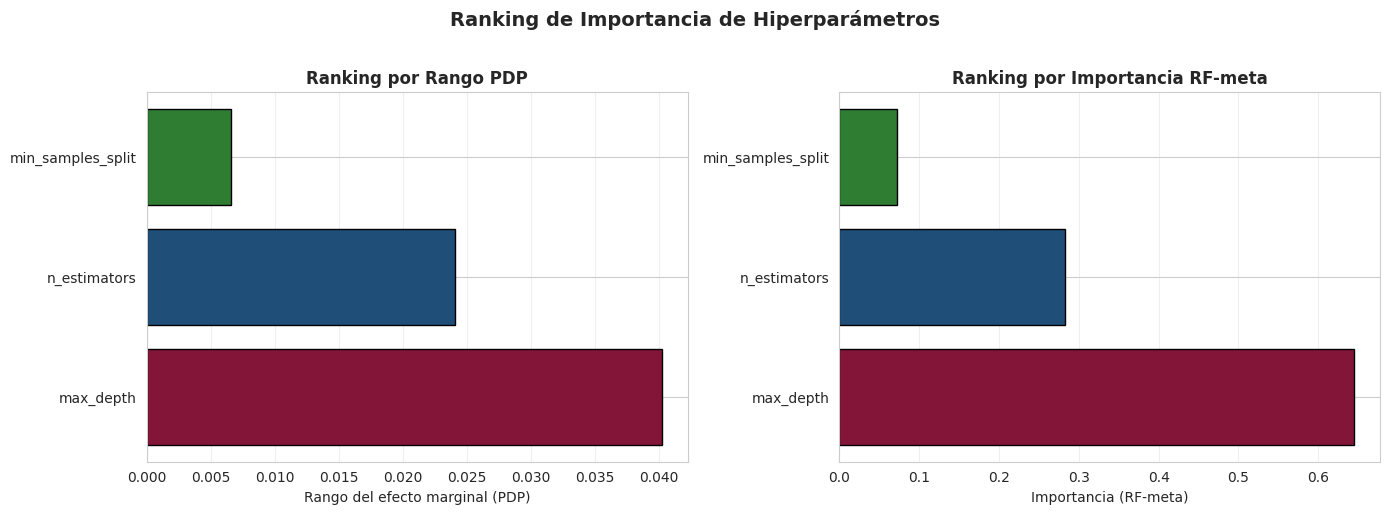

In [17]:
from sklearn.ensemble import RandomForestRegressor

# Ranking por rango del efecto PDP
pdp_ranges = {
    'n_estimators': pdp_n['mean'].max() - pdp_n['mean'].min(),
    'max_depth': pdp_d['mean'].max() - pdp_d['mean'].min(),
    'min_samples_split': pdp_s['mean'].max() - pdp_s['mean'].min(),
}

# Ranking por importancia de Random Forest meta-modelo
X_meta = df_exp[['n_estimators','max_depth','min_samples_split']].values
y_meta = df_exp['F1 Macro'].values
meta = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE).fit(X_meta, y_meta)
meta_importance = dict(zip(['n_estimators','max_depth','min_samples_split'], meta.feature_importances_))

ranking = pd.DataFrame({
    'Hiperparámetro': ['n_estimators', 'max_depth', 'min_samples_split'],
    'Rango PDP': [pdp_ranges[k] for k in ['n_estimators','max_depth','min_samples_split']],
    'Importancia RF-meta': [meta_importance[k] for k in ['n_estimators','max_depth','min_samples_split']],
})
ranking['Score combinado'] = (ranking['Rango PDP']/ranking['Rango PDP'].max() +
                               ranking['Importancia RF-meta']/ranking['Importancia RF-meta'].max()) / 2
ranking = ranking.sort_values('Score combinado', ascending=False).reset_index(drop=True)
ranking['Ranking'] = range(1, len(ranking)+1)
ranking = ranking[['Ranking', 'Hiperparámetro', 'Rango PDP', 'Importancia RF-meta', 'Score combinado']]

print("🏅 RANKING DE IMPORTANCIA DE HIPERPARÁMETROS:\n")
print(ranking.to_string(index=False))

# Visualización ranking
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.barh(ranking['Hiperparámetro'], ranking['Rango PDP'],
        color=['#821538','#1F4E79','#2E7D32'][:len(ranking)], edgecolor='black')
ax.set_xlabel('Rango del efecto marginal (PDP)')
ax.set_title('Ranking por Rango PDP', fontweight='bold'); ax.grid(alpha=0.3, axis='x')

ax = axes[1]
ax.barh(ranking['Hiperparámetro'], ranking['Importancia RF-meta'],
        color=['#821538','#1F4E79','#2E7D32'][:len(ranking)], edgecolor='black')
ax.set_xlabel('Importancia (RF-meta)')
ax.set_title('Ranking por Importancia RF-meta', fontweight='bold'); ax.grid(alpha=0.3, axis='x')

plt.suptitle('Ranking de Importancia de Hiperparámetros',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('fig10_ranking_hp.png', dpi=130, bbox_inches='tight'); plt.show()

## 2.4. Análisis de interacciones (mapa de calor 2D)

Se estudia si existen sinergias o conflictos entre pares de hiperparámetros mediante mapas de calor de F1 promedio.

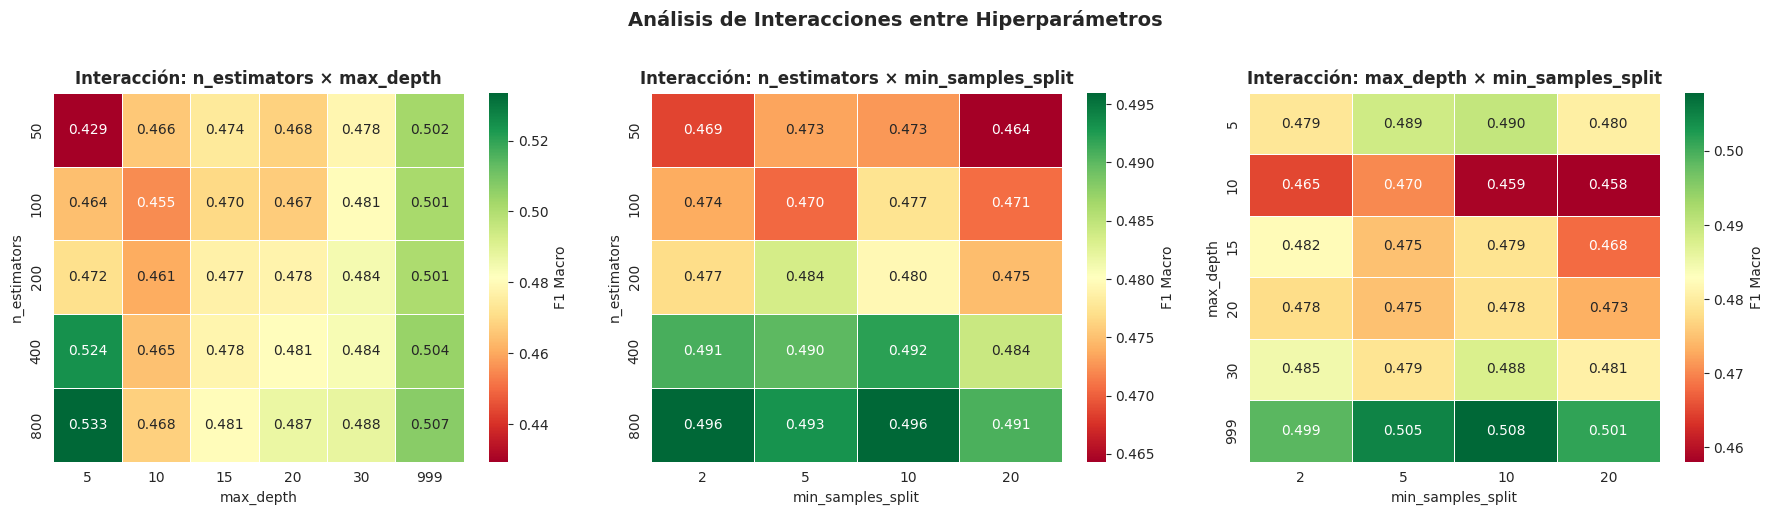

✅ Figura guardada: fig11_interacciones_hp.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (hp1, hp2) in zip(axes, [
    ('n_estimators', 'max_depth'),
    ('n_estimators', 'min_samples_split'),
    ('max_depth', 'min_samples_split')
]):
    pivot = df_exp.pivot_table(index=hp1, columns=hp2, values='F1 Macro', aggfunc='mean')
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax,
                cbar_kws={'label': 'F1 Macro'}, linewidths=0.5, linecolor='white')
    ax.set_title(f'Interacción: {hp1} × {hp2}', fontweight='bold')

plt.suptitle('Análisis de Interacciones entre Hiperparámetros',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('fig11_interacciones_hp.png', dpi=130, bbox_inches='tight'); plt.show()
print("✅ Figura guardada: fig11_interacciones_hp.png")

## 3. Síntesis final y exportación de resultados

Guardado de todas las tablas generadas como CSV para importar al informe Word y asegurar reproducibilidad.

In [19]:
# Guardar todas las tablas
df_noise.to_csv('res_actividad1_ruido.csv', index=False)
df_drift.to_csv('res_actividad2_drift.csv', index=False)
df_stress.to_csv('res_actividad3_estres.csv', index=False)
df_atypical.to_csv('res_actividad3_atipicos.csv', index=False)
df_adv.to_csv('res_actividad4_adversarial.csv', index=False)
df_all.to_csv('res_consolidado_fallos.csv', index=False)
ranking.to_csv('res_ranking_hp.csv', index=False)

print("✅ Todos los resultados exportados a CSV.\n")
print("=" * 70)
print("RESUMEN EJECUTIVO")
print("=" * 70)
print(f"\n📌 BASELINE:  Accuracy={baseline_acc:.4f}  |  F1 Macro={baseline_f1:.4f}")
print(f"\n📌 PEORES PERTURBACIONES (ranking):")
print(df_all.head(5)[['Familia','Detalle','Degradación (%)','Estado']].to_string(index=False))
print(f"\n📌 MEJORES HIPERPARÁMETROS (top 3):")
print(df_exp.nlargest(3, 'F1 Macro')[['n_estimators','max_depth','min_samples_split','F1 Macro']].to_string(index=False))
print(f"\n📌 HIPERPARÁMETRO MÁS INFLUYENTE: {ranking.iloc[0]['Hiperparámetro']}")
print("\n" + "=" * 70)
print("✅ Notebook completado correctamente. Figuras y CSVs guardados.")
print("=" * 70)

✅ Todos los resultados exportados a CSV.

RESUMEN EJECUTIVO

📌 BASELINE:  Accuracy=0.6634  |  F1 Macro=0.4733

📌 PEORES PERTURBACIONES (ranking):
Familia           Detalle  Degradación (%)       Estado
  Ruido    Outliers (20%)        89.315210    🔴 Crítico
  Ruido Gaussiano (σ=0.2)        86.601150    🔴 Crítico
  Ruido Gaussiano (σ=0.1)        62.072090    🔴 Crítico
  Ruido    Outliers (10%)        61.234946    🔴 Crítico
  Ruido     Outliers (5%)        20.630797 🟠 Vulnerable

📌 MEJORES HIPERPARÁMETROS (top 3):
 n_estimators  max_depth  min_samples_split  F1 Macro
          800          5                  2  0.537316
          800          5                 10  0.536267
          800          5                 20  0.532697

📌 HIPERPARÁMETRO MÁS INFLUYENTE: max_depth

✅ Notebook completado correctamente. Figuras y CSVs guardados.
